In [40]:
from google.colab import files
uploaded = files.upload()

Saving FertilizerData.csv to FertilizerData (3).csv
Saving MergeFileCrop.csv to MergeFileCrop (3).csv


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

fert_df = pd.read_csv('FertilizerData.csv', sep=';')
crop_df = pd.read_csv('MergeFileCrop.csv', sep=';')
print(crop_df.shape)
print(crop_df.head())
print(fert_df.head())

(2200, 6)
  Unnamed: 0  temperature   humidity        ph    rainfall label
0          0    20.879744  82.002744  6.502985  202.935536  rice
1          1    21.770462  80.319644  7.038096  226.655537  rice
2          2    23.004459  82.320763  7.840207  263.964248  rice
3          3    26.491096  80.158363  6.980401  242.864034  rice
4          4    20.130175  81.604873  7.628473  262.717340  rice
   Unnamed: 0         Crop   N   P   K   pH
0           0         rice  80  40  40  5.5
1           3        maize  80  40  20  5.5
2           5     chickpea  40  60  80  5.5
3          12  kidneybeans  20  60  20  5.5
4          13   pigeonpeas  20  60  20  5.5


In [42]:
print(crop_df.isnull().sum())
print(fert_df.isnull().sum())

print(crop_df.columns)
print(fert_df.columns)

Unnamed: 0     0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64
Unnamed: 0    0
Crop          0
N             0
P             0
K             0
pH            0
dtype: int64
Index(['Unnamed: 0', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')
Index(['Unnamed: 0', 'Crop', 'N', 'P', 'K', 'pH'], dtype='object')


In [43]:
fert_df.rename(columns={'Crop':'label'}, inplace=True)

merged_df = crop_df.merge(fert_df, on='label', how='left')
print(merged_df.shape)
print(merged_df.head())

(2200, 11)
  Unnamed: 0_x  temperature   humidity        ph    rainfall label  \
0            0    20.879744  82.002744  6.502985  202.935536  rice   
1            1    21.770462  80.319644  7.038096  226.655537  rice   
2            2    23.004459  82.320763  7.840207  263.964248  rice   
3            3    26.491096  80.158363  6.980401  242.864034  rice   
4            4    20.130175  81.604873  7.628473  262.717340  rice   

   Unnamed: 0_y   N   P   K   pH  
0             0  80  40  40  5.5  
1             0  80  40  40  5.5  
2             0  80  40  40  5.5  
3             0  80  40  40  5.5  
4             0  80  40  40  5.5  


In [44]:
# Analysis 1: Average inputs per crop

input_analysis = merged_df.groupby('label')[['N','P','K']].mean().reset_index()
input_analysis['total_input'] = input_analysis['N'] + input_analysis['P'] + input_analysis['K']
input_analysis = input_analysis.sort_values('total_input')
print(input_analysis)

          label      N      P      K  total_input
16       orange   20.0   10.0   10.0         40.0
4       coconut   20.0   10.0   30.0         60.0
19  pomegranate   20.0   10.0   40.0         70.0
12        mango   20.0   20.0   30.0         70.0
13    mothbeans   20.0   40.0   20.0         80.0
14     mungbean   20.0   40.0   20.0         80.0
9   kidneybeans   20.0   60.0   20.0        100.0
10       lentil   20.0   60.0   20.0        100.0
18   pigeonpeas   20.0   60.0   20.0        100.0
2     blackgram   40.0   60.0   20.0        120.0
11        maize   80.0   40.0   20.0        140.0
5        coffee  100.0   20.0   30.0        150.0
17       papaya   50.0   50.0   50.0        150.0
8          jute   80.0   40.0   40.0        160.0
15    muskmelon  100.0   10.0   50.0        160.0
20         rice   80.0   40.0   40.0        160.0
21   watermelon  100.0   10.0   50.0        160.0
3      chickpea   40.0   60.0   80.0        180.0
6        cotton  120.0   40.0   20.0        180.0


/tmp/ipykernel_3952/3071371328.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= input_analysis, x='label', y='total_input', palette='Greens_r')


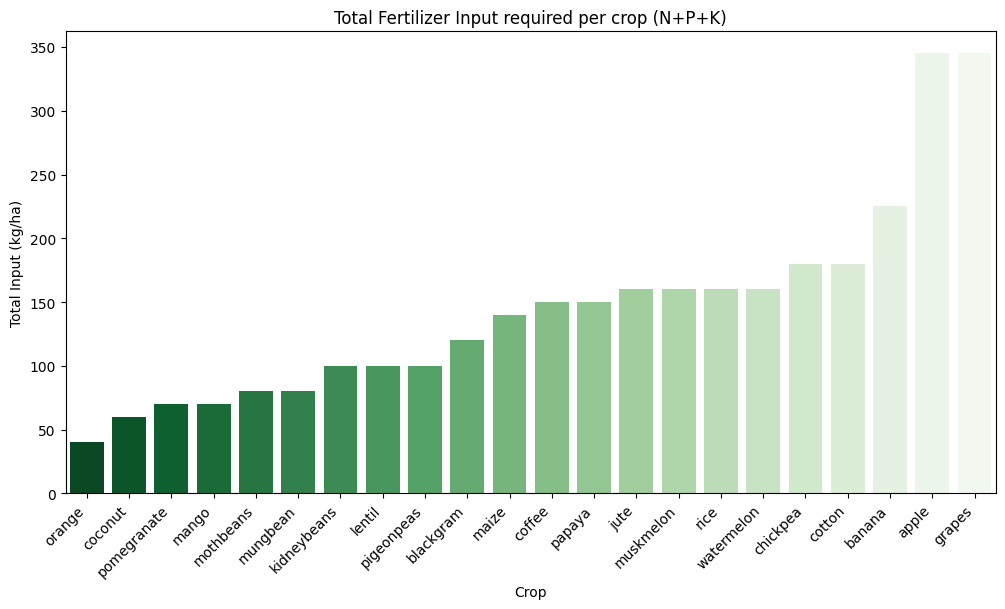

In [45]:
# Analysis 2: Crops needing least totl fertilizer input

plt.figure(figsize=(12, 6))
sns.barplot(data= input_analysis, x='label', y='total_input', palette='Greens_r')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Crop')
plt.ylabel('Total Input (kg/ha)')
plt.title('Total Fertilizer Input required per crop (N+P+K)')
plt.savefig('Input_cost_chart.png')
plt.show()

In [46]:
# Analysis 3: Rainfall vs Input efficiency

climate = merged_df.groupby('label')[['temperature','humidity', 'rainfall']].mean().reset_index()
efficiency = input_analysis.merge(climate, on='label')
efficiency['efficiency_score'] = efficiency['rainfall'] / (efficiency['total_input'])
efficiency = efficiency.sort_values('efficiency_score', ascending=False)
print(efficiency[['label', 'total_input', 'efficiency_score']].head(10))

          label  total_input  efficiency_score
1       coconut         60.0          2.928111
0        orange         40.0          2.761874
2   pomegranate         70.0          1.536121
8    pigeonpeas        100.0          1.494576
15         rice        160.0          1.476132
3         mango         70.0          1.352922
13         jute        160.0          1.092455
6   kidneybeans        100.0          1.059198
11       coffee        150.0          1.053775
12       papaya        150.0          0.950852


In [47]:
merged_df.to_csv('farm_input_optimiser_clean.csv', index=False)
efficiency.to_csv('efficiency_summary.csv', index=False)
files.download('farm_input_optimiser_clean.csv')
files.download('efficiency_summary.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>